In [1]:
# ============================================================
# 00 — CONNECT GOOGLE DRIVE / PROJECT
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# ============================================================
# PROJECT PATH
# ============================================================

from pathlib import Path
import sys

PROJECT_DIR = Path(
    "/content/drive/MyDrive/FitnessML_Master"
)

print(f"Project directory: {PROJECT_DIR}")
print(f"Exists: {PROJECT_DIR.exists()}")

Project directory: /content/drive/MyDrive/FitnessML_Master
Exists: True


In [4]:
# ============================================================
# ADD PROJECT TO PYTHON PATH
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import config_fitbit as config

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("=" * 70)
print("FITBIT MODEL VALIDATION")
print("=" * 70)

FITBIT MODEL VALIDATION


In [5]:
# ============================================================
# LOAD MODELING DATASET
# ============================================================

model_path = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "fitbit_modeling_features.csv"
)

model_df = pd.read_csv(model_path)

model_df["ActivityDate"] = pd.to_datetime(
    model_df["ActivityDate"]
)

model_df = (
    model_df
    .sort_values(["ActivityDate", "Id"])
    .reset_index(drop=True)
)

print("=" * 70)
print("MODEL DATASET")
print("=" * 70)

print(f"Shape: {model_df.shape}")
print(f"Users: {model_df['Id'].nunique()}")
print(
    f"Date range: "
    f"{model_df['ActivityDate'].min().date()} → "
    f"{model_df['ActivityDate'].max().date()}"
)

display(model_df.head())

MODEL DATASET
Shape: (680, 68)
Users: 32
Date range: 2016-04-19 → 2016-05-11


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Calories_lag_1,Calories_lag_2,Calories_lag_3,Calories_lag_7,TotalSteps_lag_1,TotalSteps_lag_2,TotalSteps_lag_3,TotalSteps_lag_7,TotalDistance_lag_1,TotalDistance_lag_2,TotalDistance_lag_3,TotalDistance_lag_7,VeryActiveMinutes_lag_1,VeryActiveMinutes_lag_2,VeryActiveMinutes_lag_3,VeryActiveMinutes_lag_7,FairlyActiveMinutes_lag_1,FairlyActiveMinutes_lag_2,FairlyActiveMinutes_lag_3,FairlyActiveMinutes_lag_7,LightlyActiveMinutes_lag_1,LightlyActiveMinutes_lag_2,LightlyActiveMinutes_lag_3,LightlyActiveMinutes_lag_7,SedentaryMinutes_lag_1,SedentaryMinutes_lag_2,SedentaryMinutes_lag_3,SedentaryMinutes_lag_7,Calories_rolling_mean_3,Calories_rolling_std_3,Calories_rolling_mean_7,Calories_rolling_std_7,TotalSteps_rolling_mean_3,TotalSteps_rolling_std_3,TotalSteps_rolling_mean_7,TotalSteps_rolling_std_7,TotalDistance_rolling_mean_3,TotalDistance_rolling_std_3,TotalDistance_rolling_mean_7,TotalDistance_rolling_std_7,VeryActiveMinutes_rolling_mean_3,VeryActiveMinutes_rolling_std_3,VeryActiveMinutes_rolling_mean_7,VeryActiveMinutes_rolling_std_7,LightlyActiveMinutes_rolling_mean_3,LightlyActiveMinutes_rolling_std_3,LightlyActiveMinutes_rolling_mean_7,LightlyActiveMinutes_rolling_std_7,SedentaryMinutes_rolling_mean_3,SedentaryMinutes_rolling_std_3,SedentaryMinutes_rolling_mean_7,SedentaryMinutes_rolling_std_7,target_calories_next_day
0,1503960366,2016-04-19,15506,9.88,9.88,0.0,3.53,1.32,5.03,0.0,50,31,264,775,2035,1921.0,1728.0,1863.0,1985.0,13019.0,9705.0,12669.0,13162.0,8.59,6.48,8.16,8.50,42.0,38.0,36.0,25.0,16.0,20.0,10.0,13.0,233.0,164.0,221.0,328.0,1149.0,539.0,773.0,728.0,1837.333333,99.026932,1830.714286,95.764841,11797.666667,1820.732087,11358.857143,1538.733833,7.743333,1.115004,7.388571,0.993654,38.666667,3.055050,31.571429,7.457818,206.000000,36.864617,221.857143,52.594133,820.333333,307.742316,844.142857,245.957604,1786.0
1,1624580081,2016-04-19,2916,1.90,1.90,0.0,0.00,0.00,1.90,0.0,0,0,141,1299,1435,1604.0,1554.0,1463.0,1432.0,10536.0,6175.0,5370.0,8163.0,7.41,4.06,3.49,5.31,17.0,15.0,0.0,0.0,7.0,22.0,0.0,0.0,202.0,127.0,176.0,146.0,1214.0,1276.0,1264.0,1294.0,1540.333333,71.486595,1482.857143,95.837412,7360.333333,2779.505412,6838.285714,2932.289419,4.986667,2.117931,4.531429,2.030611,10.666667,9.291573,4.571429,7.828519,168.333333,38.083242,161.571429,47.088063,1251.333333,32.883633,1269.714286,48.475816,1446.0
2,1644430081,2016-04-19,11256,8.18,8.18,0.0,0.36,2.53,5.30,0.0,5,58,278,1099,3300,2806.0,3011.0,3493.0,3199.0,7132.0,8757.0,15300.0,10694.0,5.19,6.37,11.12,7.77,15.0,29.0,51.0,2.0,33.0,13.0,42.0,51.0,121.0,186.0,212.0,256.0,1271.0,1212.0,1135.0,1131.0,3103.333333,352.684467,3055.285714,265.264468,10396.333333,4323.727134,9454.857143,3260.173381,7.560000,3.138997,6.874286,2.366832,31.666667,18.147543,19.285714,18.263938,173.000000,46.872167,190.285714,53.049393,1206.000000,68.198240,1199.428571,67.384116,2430.0
3,1844505072,2016-04-19,197,0.13,0.13,0.0,0.00,0.00,0.13,0.0,0,0,10,1430,1366,1814.0,1793.0,1657.0,2030.0,4597.0,4525.0,3414.0,6697.0,3.04,2.99,2.26,4.43,0.0,2.0,0.0,0.0,12.0,8.0,0.0,0.0,217.0,199.0,147.0,339.0,1211.0,1231.0,1293.0,1101.0,1754.666667,85.231059,1858.428571,167.243193,4178.666667,663.198563,5134.714286,1613.668152,2.763333,0.436616,3.395714,1.067690,0.666667,1.154701,0.285714,0.755929,187.666667,36.350149,242.714286,84.120379,1245.000000,42.755117,1056.857143,275.845626,1349.0
4,1927972279,2016-04-19,0,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0,0,0,1440,2063,2111.0,2063.0,2064.0,2220.0,244.0,0.0,0.0,678.0,0.17,0.00,0.00,0.47,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.0,0.0,0.0,55.0,1423.0,1440.0,1440.0,734.0,2079.333333,27.428695,2173.285714,113.226490,81.333333,140.873466,631.571429,762.970916,0.056667,0.098150,0.438571,0.528880,0.000000,0.000000,0.000000,0.0000

In [6]:
# ============================================================
# FEATURE DEFINITIONS
# ============================================================

target_column = "target_calories_next_day"

base_features = [
    "TotalSteps",
    "TotalDistance",
    "TrackerDistance",
    "LoggedActivitiesDistance",
    "VeryActiveDistance",
    "ModeratelyActiveDistance",
    "LightActiveDistance",
    "SedentaryActiveDistance",
    "VeryActiveMinutes",
    "FairlyActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes",
    "Calories"
]

lag_features = [
    c for c in model_df.columns
    if "_lag_" in c
]

rolling_features = [
    c for c in model_df.columns
    if "rolling_" in c
]

all_features = (
    base_features +
    lag_features +
    rolling_features
)

print("=" * 70)
print("FEATURE SETS")
print("=" * 70)

print(f"Base features:    {len(base_features)}")
print(f"Lag features:     {len(lag_features)}")
print(f"Rolling features: {len(rolling_features)}")
print(f"All features:     {len(all_features)}")
print(f"Target:           {target_column}")

FEATURE SETS
Base features:    13
Lag features:     28
Rolling features: 24
All features:     65
Target:           target_calories_next_day


In [15]:
# ============================================================
# TEMPORAL WALK-FORWARD FOLDS
# ============================================================

unique_dates = np.sort(
    model_df["ActivityDate"].unique()
)

n_dates = len(unique_dates)

# ------------------------------------------------------------
# Validation design
# ------------------------------------------------------------
# Initial training window: 8 days
# Test window:            5 days
# Number of folds:        3
#
# Fold 1: 8 train days  -> 5 test days
# Fold 2: 13 train days -> 5 test days
# Fold 3: 18 train days -> 5 test days
# ------------------------------------------------------------

initial_train_size = 8
test_size = 5
n_folds = 3

folds = []

for fold in range(n_folds):

    train_end = (
        initial_train_size +
        fold * test_size
    )

    test_start = train_end
    test_end = test_start + test_size

    if test_end > n_dates:
        break

    train_dates = unique_dates[:train_end]

    test_dates = unique_dates[
        test_start:test_end
    ]

    train_fold = model_df[
        model_df["ActivityDate"].isin(train_dates)
    ].copy()

    test_fold = model_df[
        model_df["ActivityDate"].isin(test_dates)
    ].copy()

    folds.append(
        {
            "fold": fold + 1,
            "train": train_fold,
            "test": test_fold
        }
    )


print("=" * 70)
print("WALK-FORWARD FOLDS")
print("=" * 70)

for f in folds:

    train_fold = f["train"]
    test_fold = f["test"]

    print(
        f"Fold {f['fold']}: "
        f"train "
        f"{train_fold['ActivityDate'].min().date()} → "
        f"{train_fold['ActivityDate'].max().date()} "
        f"({len(train_fold)} rows) | "
        f"test "
        f"{test_fold['ActivityDate'].min().date()} → "
        f"{test_fold['ActivityDate'].max().date()} "
        f"({len(test_fold)} rows)"
    )

WALK-FORWARD FOLDS
Fold 1: train 2016-04-19 → 2016-04-26 (256 rows) | test 2016-04-27 → 2016-05-01 (154 rows)
Fold 2: train 2016-04-19 → 2016-05-01 (410 rows) | test 2016-05-02 → 2016-05-06 (145 rows)
Fold 3: train 2016-04-19 → 2016-05-06 (555 rows) | test 2016-05-07 → 2016-05-11 (125 rows)


In [16]:
# ============================================================
# MODEL DEFINITIONS
# ============================================================

models = {
    "Linear Regression — Base": {
        "model": LinearRegression(),
        "features": base_features
    },

    "Decision Tree — Base": {
        "model": DecisionTreeRegressor(
            max_depth=5,
            random_state=42
        ),
        "features": base_features
    },

    "Random Forest — All Features": {
        "model": RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ),
        "features": all_features
    }
}

print("=" * 70)
print("VALIDATION MODELS")
print("=" * 70)

for name in models:
    print(name)

VALIDATION MODELS
Linear Regression — Base
Decision Tree — Base
Random Forest — All Features


In [17]:
# ============================================================
# WALK-FORWARD VALIDATION
# ============================================================

validation_results = []

for fold_info in folds:

    fold_number = fold_info["fold"]
    train_fold = fold_info["train"]
    test_fold = fold_info["test"]

    y_train = train_fold[target_column]
    y_test = test_fold[target_column]

    # --------------------------------------------------------
    # ML MODELS
    # --------------------------------------------------------

    for model_name, model_info in models.items():

        X_train = train_fold[
            model_info["features"]
        ]

        X_test = test_fold[
            model_info["features"]
        ]

        model = model_info["model"]

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        validation_results.append({
            "fold": fold_number,
            "model": model_name,
            "MAE": mean_absolute_error(
                y_test,
                predictions
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    y_test,
                    predictions
                )
            ),
            "R2": r2_score(
                y_test,
                predictions
            )
        })

    # --------------------------------------------------------
    # USER MEAN BASELINE
    # --------------------------------------------------------

    user_means = (
        train_fold
        .groupby("Id")["Calories"]
        .mean()
    )

    user_predictions = (
        test_fold["Id"]
        .map(user_means)
        .fillna(
            train_fold["Calories"].mean()
        )
    )

    validation_results.append({
        "fold": fold_number,
        "model": "User Mean",
        "MAE": mean_absolute_error(
            y_test,
            user_predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                user_predictions
            )
        ),
        "R2": r2_score(
            y_test,
            user_predictions
        )
    })

    # --------------------------------------------------------
    # 7-DAY MEAN BASELINE
    # --------------------------------------------------------

    seven_day_predictions = (
        test_fold["Calories_rolling_mean_7"]
    )

    validation_results.append({
        "fold": fold_number,
        "model": "7-Day Mean",
        "MAE": mean_absolute_error(
            y_test,
            seven_day_predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                seven_day_predictions
            )
        ),
        "R2": r2_score(
            y_test,
            seven_day_predictions
        )
    })


validation_df = pd.DataFrame(
    validation_results
)

print("=" * 70)
print("WALK-FORWARD VALIDATION RESULTS")
print("=" * 70)

display(
    validation_df
    .round(4)
)

WALK-FORWARD VALIDATION RESULTS


,fold,model,MAE,RMSE,R2
0,1,Linear Regression — Base,329.5015,480.6749,0.5043
1,1,Decision Tree — Base,342.2142,487.1548,0.4908
2,1,Random Forest — All Features,306.6998,457.4075,0.5511
3,1,User Mean,309.9253,472.9151,0.5202
4,1,7-Day Mean,301.7430,457.5677,0.5508
5,2,Linear Regression — Base,343.6118,510.4567,0.4788
6,2,Decision Tree — Base,375.3805,541.0373,0.4145
7,2,Random Forest — All Features,332.9400,493.5887,0.5127
8,2,User Mean,307.0918,492.3721,0.5151
9,2,7-Day Mean,317.6266,483.6338,0.5321


In [18]:
# ============================================================
# VALIDATION STABILITY SUMMARY
# ============================================================

validation_summary = (
    validation_df
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),

        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),

        R2_mean=("R2", "mean"),
        R2_std=("R2", "std")
    )
    .sort_values(
        "RMSE_mean"
    )
)

print("=" * 70)
print("VALIDATION STABILITY SUMMARY")
print("=" * 70)

display(
    validation_summary
    .round(4)
)

VALIDATION STABILITY SUMMARY


,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
model,,,,,,
Random Forest — All Features,373.7911,94.3970,563.8099,154.0266,0.4381,0.1637
7-Day Mean,366.4455,98.6326,566.3899,166.4228,0.4325,0.1890
User Mean,367.9359,102.9410,572.8226,156.4973,0.4199,0.1693
Linear Regression — Base,389.7171,92.3465,576.5766,141.1027,0.4124,0.1377
Decision Tree — Base,404.6027,81.0518,582.5245,121.5451,0.3992,0.1001


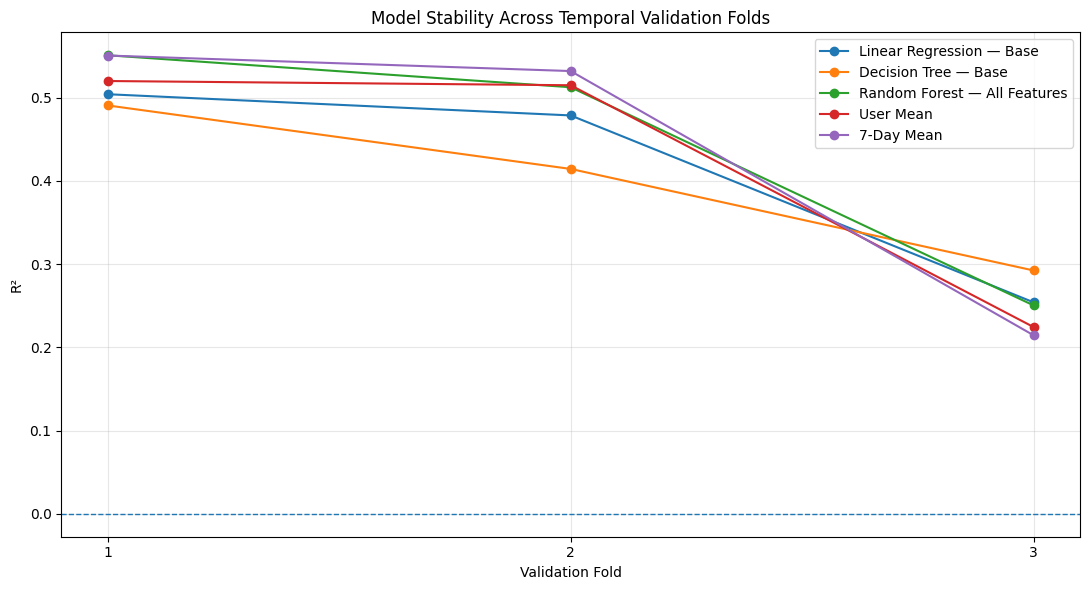

In [19]:
# ============================================================
# R2 STABILITY BY FOLD
# ============================================================

plt.figure(figsize=(11, 6))

for model_name in validation_df["model"].unique():

    subset = validation_df[
        validation_df["model"] == model_name
    ]

    plt.plot(
        subset["fold"],
        subset["R2"],
        marker="o",
        label=model_name
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Validation Fold")
plt.ylabel("R²")
plt.title("Model Stability Across Temporal Validation Folds")
plt.xticks(
    sorted(validation_df["fold"].unique())
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# SAVE VALIDATION RESULTS
# ============================================================

tables_dir = PROJECT_DIR / "tables"
reports_dir = PROJECT_DIR / "reports"
figures_dir = PROJECT_DIR / "figures"

tables_dir.mkdir(
    parents=True,
    exist_ok=True
)

reports_dir.mkdir(
    parents=True,
    exist_ok=True
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Raw fold results
validation_path = (
    tables_dir /
    "006_validation_results.csv"
)

validation_df.to_csv(
    validation_path,
    index=False
)

# Summary
summary_path = (
    tables_dir /
    "006_validation_summary.csv"
)

validation_summary.to_csv(
    summary_path
)

print("=" * 70)
print("006 RESULTS SAVED")
print("=" * 70)

print(f"Fold results: {validation_path}")
print(f"Summary:      {summary_path}")

006 RESULTS SAVED
Fold results: /content/drive/MyDrive/FitnessML_Master/tables/006_validation_results.csv
Summary:      /content/drive/MyDrive/FitnessML_Master/tables/006_validation_summary.csv
